# Importância das Variáveis — Cinco Modelos Finais

Explicabilidade consolidada dos cinco modelos avaliados na dissertação. Como as métricas de
importância têm semântica e escala distintas entre algoritmos, os resultados são apresentados
por família de modelo e interpretados de forma **qualitativa** (convergência de preditores),
sem comparação direta de magnitudes entre algoritmos.

- **Parte 1 — Modelos de árvore** (Árvore de Decisão, Random Forest, XGBoost, LightGBM):
  importância por redução de impureza (MDI/Gini) ou ganho (*gain*).
- **Parte 2 — Regressão Logística**: importância pelos coeficientes padronizados e
  razões de chances (OR = exp(β)) com intervalos de confiança de 95%.

In [13]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

OUTPUT_MOD = '../../output/modelos'
OUTPUT_PLT = '../../output/plots'
os.makedirs(OUTPUT_PLT, exist_ok=True)

TOP_N = 10

In [14]:
modelos = {
    'Decision Tree': joblib.load(os.path.join(OUTPUT_MOD, 'decision_tree_baseline.joblib')),
    'Random Forest': joblib.load(os.path.join(OUTPUT_MOD, 'random_forest_baseline_tuned.joblib')),
    'XGBoost':       joblib.load(os.path.join(OUTPUT_MOD, 'xgboost_baseline_tuned.joblib')),
    'LightGBM':      joblib.load(os.path.join(OUTPUT_MOD, 'lightgbm_baseline_tuned.joblib')),
}

for nome, pipeline in modelos.items():
    n_features = len(pipeline['pre'].get_feature_names_out())
    print(f'{nome}: {n_features} features')

Decision Tree: 60 features
Random Forest: 60 features
XGBoost: 51 features
LightGBM: 51 features


In [15]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

importance_methods = {
    'Decision Tree': 'MDI/Gini',
    'Random Forest': 'MDI/Gini',
    'XGBoost':       'gain',
    'LightGBM':      'gain',
}

dfs = {}
for nome, pipeline in modelos.items():
    feature_names = pipeline['pre'].get_feature_names_out()
    clf = pipeline['clf']

    if isinstance(clf, XGBClassifier):
        booster = clf.get_booster()
        score_dict = booster.get_score(importance_type='gain')
        # Booster usa nomes posicionais internos ('f0','f1',...) quando treinado
        # via sklearn Pipeline — iteramos sobre eles para alinhar por posição.
        booster_fnames = booster.feature_names or [f'f{i}' for i in range(len(feature_names))]
        importances = np.array([score_dict.get(f, 0.0) for f in booster_fnames])
    elif isinstance(clf, LGBMClassifier):
        # array já alinhado com a ordem de features do modelo
        importances = clf.booster_.feature_importance(importance_type='gain').astype(float)
    else:
        # DecisionTreeClassifier e RandomForestClassifier usam MDI/Gini
        importances = clf.feature_importances_

    df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    df = df.sort_values('importance', ascending=False).reset_index(drop=True)
    df['rank'] = df.index + 1
    df['importance_pct'] = (df['importance'] / df['importance'].sum() * 100).round(2)
    dfs[nome] = df
    print(f'\n{nome} — top 10 (método: {importance_methods[nome]}):')
    display(df.head(10)[['rank', 'feature', 'importance', 'importance_pct']])


Decision Tree — top 10 (método: MDI/Gini):


,rank,feature,importance,importance_pct
0,1,GRAV_EXTRE,0.378297,37.83
1,2,age_years,0.237476,23.75
2,3,GRAV_CONSC,0.146154,14.62
3,4,ALRM_HIPOT,0.088735,8.87
4,5,GRAV_TAQUI,0.033135,3.31
5,6,ALRM_SANG,0.022237,2.22
6,7,GRAV_INSUF,0.014950,1.49
7,8,GRAV_HIPOT,0.014889,1.49
8,9,SG_UF,0.013621,1.36
9,10,GRAV_ORGAO,0.007049,0.70



Random Forest — top 10 (método: MDI/Gini):


,rank,feature,importance,importance_pct
0,1,age_years,0.139869,13.99
1,2,GRAV_CONSC,0.065846,6.58
2,3,GRAV_EXTRE,0.063281,6.33
3,4,epi_week,0.061148,6.11
4,5,SG_UF,0.054756,5.48
5,6,GRAV_TAQUI,0.051088,5.11
6,7,ALRM_HIPOT,0.046939,4.69
7,8,GRAV_HIPOT,0.034539,3.45
8,9,ALRM_PLAQ,0.034424,3.44
9,10,GRAV_PULSO,0.030338,3.03



XGBoost — top 10 (método: gain):


,rank,feature,importance,importance_pct
0,1,GRAV_EXTRE,3846.212402,21.17
1,2,GRAV_CONSC,2051.475098,11.29
2,3,GRAV_HIPOT,1086.817871,5.98
3,4,ALRM_HIPOT,1085.492432,5.97
4,5,HIPERTENSA,789.993408,4.35
5,6,GRAV_TAQUI,751.382812,4.14
6,7,GRAV_PULSO,688.834778,3.79
7,8,GRAV_INSUF,643.479309,3.54
8,9,ALRM_SANG,590.259094,3.25
9,10,RENAL,544.103271,2.99



LightGBM — top 10 (método: gain):


,rank,feature,importance,importance_pct
0,1,GRAV_EXTRE,436011.215523,25.40
1,2,age_years,325459.977850,18.96
2,3,GRAV_CONSC,196212.744098,11.43
3,4,SG_UF,87096.691692,5.07
4,5,ALRM_HIPOT,79149.069468,4.61
5,6,epi_week,73549.731361,4.28
6,7,GRAV_TAQUI,40977.745675,2.39
7,8,GRAV_HIPOT,39864.724234,2.32
8,9,CS_ESCOL_N,37517.638757,2.19
9,10,GRAV_INSUF,26370.585019,1.54


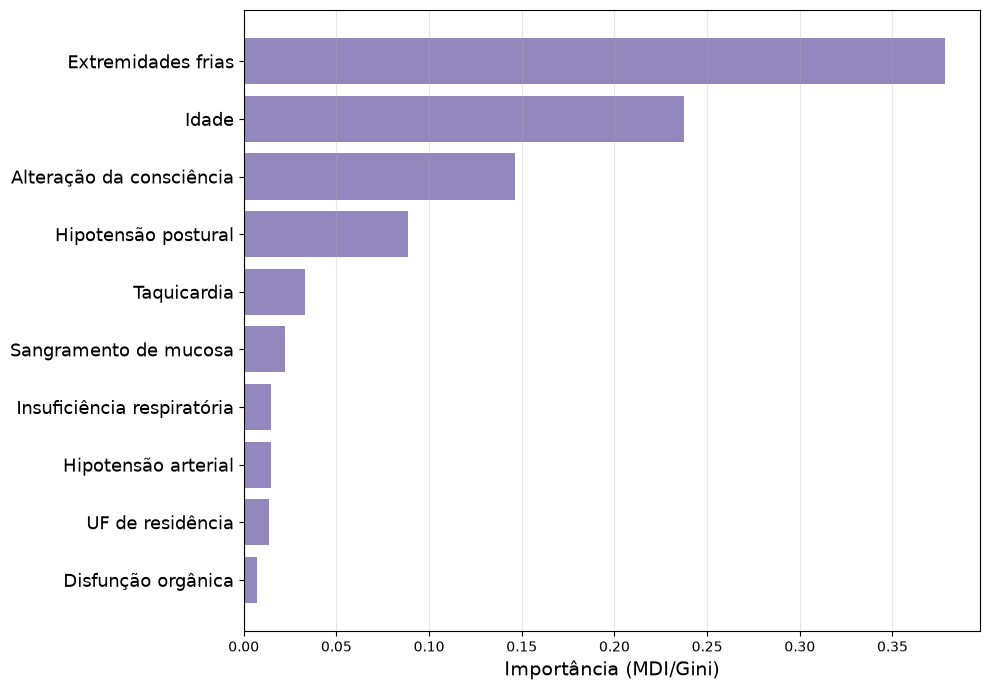

Salvo: feature_importance_decision_tree.png


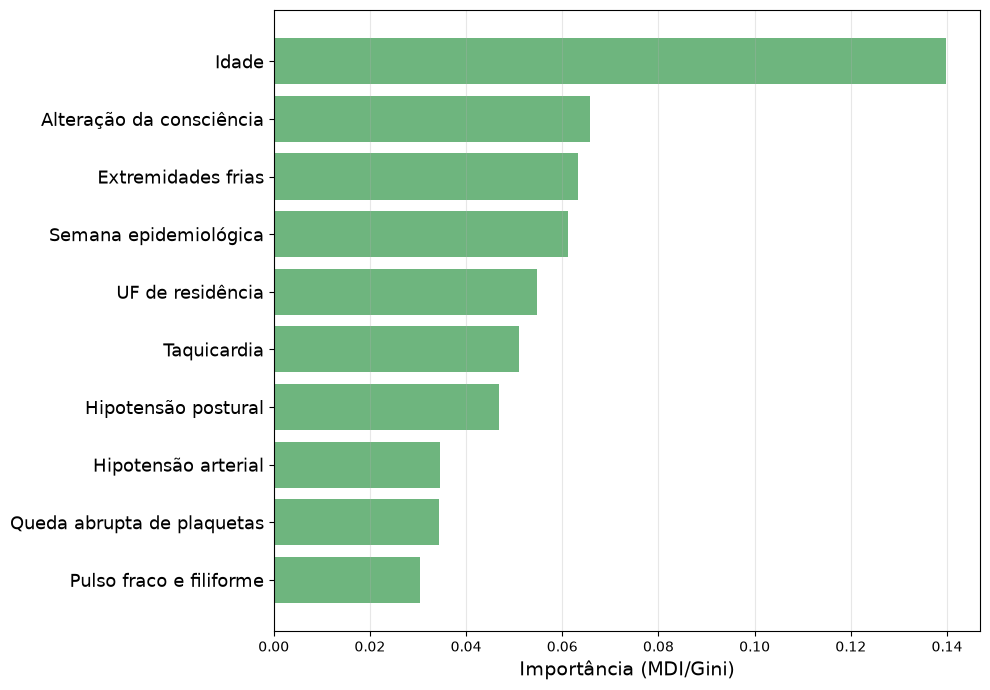

Salvo: feature_importance_random_forest.png


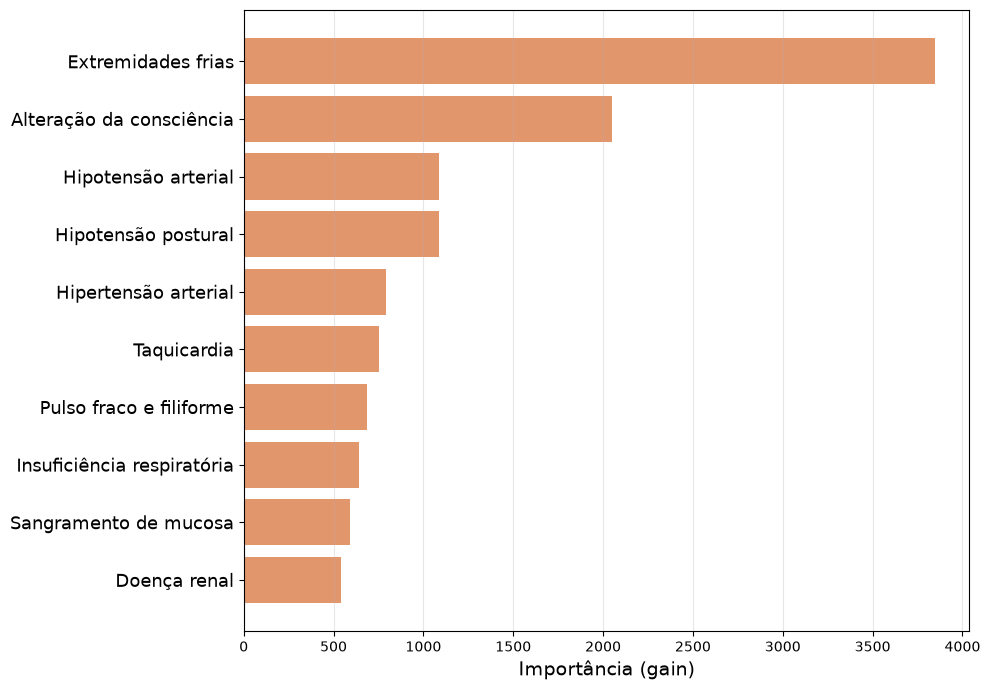

Salvo: feature_importance_xgboost.png


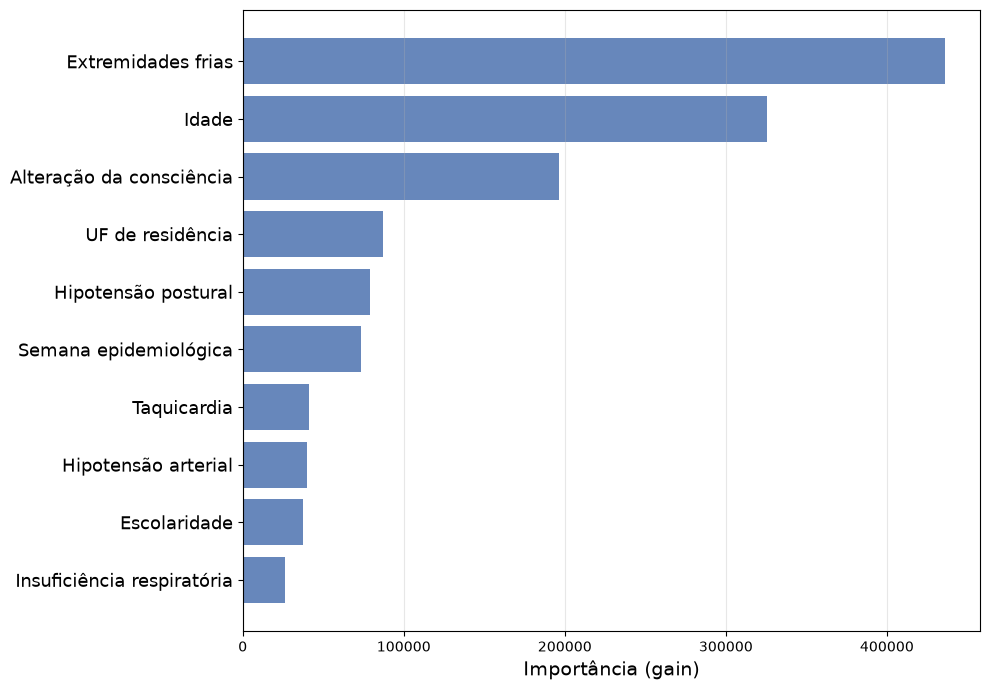

Salvo: feature_importance_lightgbm.png


In [16]:
cores = {
    'Decision Tree': '#8172B2',
    'Random Forest': '#55A868',
    'XGBoost':       '#DD8452',
    'LightGBM':      '#4C72B0',
}

xlabel_map = {
    'Decision Tree': 'Importância (MDI/Gini)',
    'Random Forest': 'Importância (MDI/Gini)',
    'XGBoost':       'Importância (gain)',
    'LightGBM':      'Importância (gain)',
}

display_names = {
    'Decision Tree': 'Árvore de Decisão',
}

feature_labels = {
    # Dados demográficos e socioeconômicos
    'age_years':      'Idade',
    'epi_week':       'Semana epidemiológica',
    'SG_UF':          'UF de residência',
    'CS_ESCOL_N':     'Escolaridade',
    'CS_RACA':        'Raça/Cor',
    'CS_GESTANT':     'Gestante',
    'CS_SEXO':        'Sexo',
    # Comorbidades
    'DIABETES':       'Diabetes',
    'HIPERTENSA':     'Hipertensão arterial',
    'AUTO_IMUNE':     'Doença autoimune',
    'HEMATOLOG':      'Doença hematológica',
    'HEPATOPAT':      'Hepatopatia',
    'RENAL':          'Doença renal',
    # Sintomas gerais
    'FEBRE':          'Febre',
    'MIALGIA':        'Mialgia',
    'CEFALEIA':       'Cefaleia',
    'EXANTEMA':       'Exantema',
    'VOMITO':         'Vômito',
    'NAUSEA':         'Náusea',
    'DOR_RETRO':      'Dor retroorbital',
    'DOR_COSTAS':     'Dor nas costas',
    'ARTRALGIA':      'Artralgia',
    'ARTRITE':        'Artrite',
    'CONJUNTVIT':     'Conjuntivite',
    'LEUCOPENIA':     'Leucopenia',
    'PETEQUIA_N':     'Petéquia',
    'LACO':           'Prova do laço',
    # Sinais de Alarme (ALRM_)
    'ALRM_HIPOT':     'Hipotensão postural',
    'ALRM_PLAQ':      'Queda abrupta de plaquetas',
    'ALRM_LETAR':     'Letargia/irritabilidade',
    'ALRM_SANG':      'Sangramento de mucosa',
    'ALRM_ABDOM':     'Dor abdominal intensa',
    'ALRM_VOM':       'Vômitos persistentes',
    'ALRM_LIQ':       'Acúmulo de líquidos',
    'ALRM_HEMAT':     'Hematócrito elevado',
    'ALRM_HEPAT':     'Hepatomegalia dolorosa',
    # Sinais de Gravidade (GRAV_)
    'GRAV_EXTRE':     'Extremidades frias',
    'GRAV_CONSC':     'Alteração da consciência',
    'GRAV_HIPOT':     'Hipotensão arterial',
    'GRAV_TAQUI':     'Taquicardia',
    'GRAV_INSUF':     'Insuficiência respiratória',
    'GRAV_PULSO':     'Pulso fraco e filiforme',
    'GRAV_ORGAO':     'Disfunção orgânica',
    'GRAV_MELEN':     'Melena',
    'GRAV_HEMAT':     'Hematêmese',
    'GRAV_SANG':      'Sangramento grave',
    'GRAV_AST':       'Elevação de AST/ALT',
    'GRAV_CONV':      'Convulsão',
    'GRAV_MIOC':      'Miocardite',
    'GRAV_METRO':     'Metrorragia',
    'GRAV_ENCH':      'Enchimento capilar lento',
    # One-hot (Random Forest / Decision Tree)
    'CS_RACA_1.0':    'Raça/Cor: Branca',
    'CS_RACA_2.0':    'Raça/Cor: Preta',
    'CS_RACA_3.0':    'Raça/Cor: Amarela',
    'CS_RACA_4.0':    'Raça/Cor: Parda',
    'CS_RACA_5.0':    'Raça/Cor: Indígena',
    'CS_GESTANT_1.0': 'Gestante: 1º trimestre',
    'CS_GESTANT_2.0': 'Gestante: 2º trimestre',
    'CS_GESTANT_3.0': 'Gestante: 3º trimestre',
    'CS_GESTANT_4.0': 'Gestante: IG ignorada',
    'CS_GESTANT_5.0': 'Não gestante',
    'CS_GESTANT_6.0': 'Não se aplica',
}

file_slug = {
    'Decision Tree': 'decision_tree',
    'Random Forest': 'random_forest',
    'XGBoost':       'xgboost',
    'LightGBM':      'lightgbm',
}

for nome in ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']:
    df_top = dfs[nome].head(TOP_N).copy()
    df_top['label'] = df_top['feature'].map(lambda f: feature_labels.get(f, f))

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(df_top['label'][::-1], df_top['importance'][::-1],
            color=cores[nome], alpha=0.85)
    ax.set_xlabel(xlabel_map[nome], fontsize=14)
    ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=13)
    plt.tight_layout()

    fname = f'feature_importance_{file_slug[nome]}.png'
    plt.savefig(os.path.join(OUTPUT_PLT, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: {fname}')

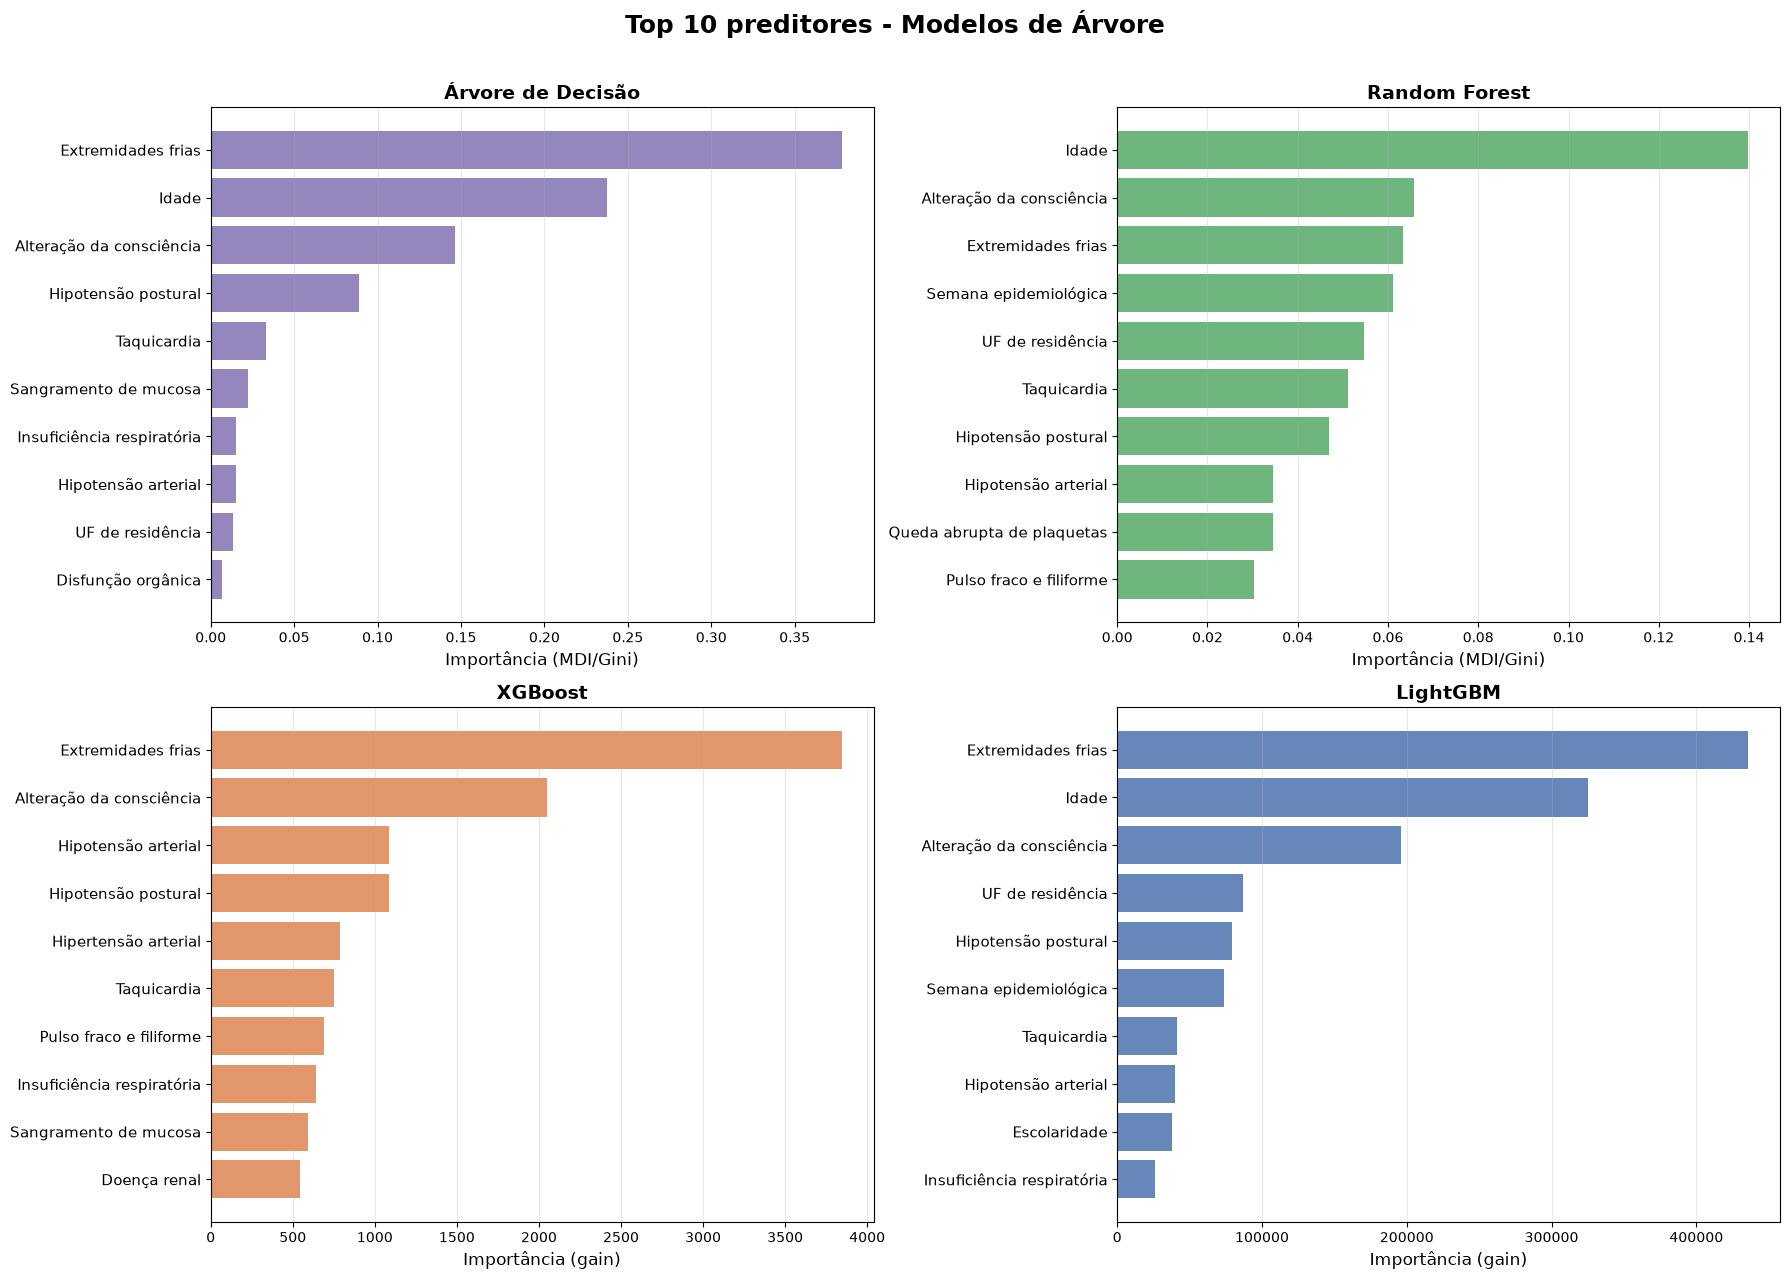

Salvo: ../../output/plots/feature_importance_grid.png (300 dpi)


In [17]:
# Grade 2x2 com os quatro gráficos de feature importance
ordem = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

for ax, nome in zip(axes.flat, ordem):
    df_top = dfs[nome].head(TOP_N).copy()
    df_top['label'] = df_top['feature'].map(lambda f: feature_labels.get(f, f))

    ax.barh(df_top['label'][::-1], df_top['importance'][::-1],
            color=cores[nome], alpha=0.85)
    ax.set_title(display_names.get(nome, nome), fontweight='bold', fontsize=14)
    ax.set_xlabel(xlabel_map[nome], fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=11)

fig.suptitle('Top 10 preditores - Modelos de Árvore', fontweight='bold', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.97])

grid_path = os.path.join(OUTPUT_PLT, 'feature_importance_grid.png')
fig.savefig(grid_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Salvo: {grid_path} (300 dpi)')

In [18]:
## Tabela resumo: método, escala e top-3 por modelo
method_display = {
    'Decision Tree': 'feature_importances_ (MDI/Gini)',
    'Random Forest': 'feature_importances_ (MDI/Gini)',
    'XGBoost':       'get_booster().get_score(importance_type="gain")',
    'LightGBM':      'booster_.feature_importance(importance_type="gain")',
}
scale_display = {
    'Decision Tree': 'normalizada (soma = 1)',
    'Random Forest': 'normalizada (soma = 1)',
    'XGBoost':       'bruta — gain (ganho médio por split)',
    'LightGBM':      'bruta — gain (ganho total por split)',
}

rows = []
for nome, df in dfs.items():
    clf = modelos[nome]['clf']
    top3 = df.head(3)['feature'].tolist()
    rows.append({
        'Modelo':               nome,
        'Tipo de classificador': type(clf).__name__,
        'Método de importância': method_display[nome],
        'Escala':               scale_display[nome],
        'Top 1':                top3[0],
        'Top 2':                top3[1],
        'Top 3':                top3[2],
    })

df_summary = pd.DataFrame(rows).set_index('Modelo')
display(df_summary)

print('\nVerificação de escala — XGBoost e LightGBM devem ter valores >> 1 (gain bruto):')
for nome in ['XGBoost', 'LightGBM']:
    vals = dfs[nome]['importance']
    print(f'  {nome}: max={vals.max():.2f}, min={vals.min():.2f}, '
          f'são inteiros pequenos? {(vals == vals.round(0)).all() and vals.max() < 50}')

,Tipo de classificador,Método de importância,Escala,Top 1,Top 2,Top 3
Modelo,,,,,,
Decision Tree,DecisionTreeClassifier,feature_importances_ (MDI/Gini),normalizada (soma = 1),GRAV_EXTRE,age_years,GRAV_CONSC
Random Forest,RandomForestClassifier,feature_importances_ (MDI/Gini),normalizada (soma = 1),age_years,GRAV_CONSC,GRAV_EXTRE
XGBoost,XGBClassifier,"get_booster().get_score(importance_type=""gain"")",bruta — gain (ganho médio por split),GRAV_EXTRE,GRAV_CONSC,GRAV_HIPOT
LightGBM,LGBMClassifier,"booster_.feature_importance(importance_type=""g...",bruta — gain (ganho total por split),GRAV_EXTRE,age_years,GRAV_CONSC



Verificação de escala — XGBoost e LightGBM devem ter valores >> 1 (gain bruto):
  XGBoost: max=3846.21, min=11.61, são inteiros pequenos? False
  LightGBM: max=436011.22, min=258.19, são inteiros pequenos? False


In [19]:
for nome, df in dfs.items():
    print(f'\n=== {nome} ===')
    display(df[['rank', 'feature', 'importance', 'importance_pct']])


=== Decision Tree ===


,rank,feature,importance,importance_pct
0,1,GRAV_EXTRE,3.782966e-01,37.83
1,2,age_years,2.374762e-01,23.75
2,3,GRAV_CONSC,1.461540e-01,14.62
3,4,ALRM_HIPOT,8.873464e-02,8.87
4,5,GRAV_TAQUI,3.313534e-02,3.31
5,6,ALRM_SANG,2.223661e-02,2.22
6,7,GRAV_INSUF,1.494978e-02,1.49
7,8,GRAV_HIPOT,1.488894e-02,1.49
8,9,SG_UF,1.362109e-02,1.36
9,10,GRAV_ORGAO,7.049356e-03,0.70



=== Random Forest ===


,rank,feature,importance,importance_pct
0,1,age_years,0.139869,13.99
1,2,GRAV_CONSC,0.065846,6.58
2,3,GRAV_EXTRE,0.063281,6.33
3,4,epi_week,0.061148,6.11
4,5,SG_UF,0.054756,5.48
5,6,GRAV_TAQUI,0.051088,5.11
6,7,ALRM_HIPOT,0.046939,4.69
7,8,GRAV_HIPOT,0.034539,3.45
8,9,ALRM_PLAQ,0.034424,3.44
9,10,GRAV_PULSO,0.030338,3.03



=== XGBoost ===


,rank,feature,importance,importance_pct
0,1,GRAV_EXTRE,3846.212402,21.17
1,2,GRAV_CONSC,2051.475098,11.29
2,3,GRAV_HIPOT,1086.817871,5.98
3,4,ALRM_HIPOT,1085.492432,5.97
4,5,HIPERTENSA,789.993408,4.35
5,6,GRAV_TAQUI,751.382812,4.14
6,7,GRAV_PULSO,688.834778,3.79
7,8,GRAV_INSUF,643.479309,3.54
8,9,ALRM_SANG,590.259094,3.25
9,10,RENAL,544.103271,2.99



=== LightGBM ===


,rank,feature,importance,importance_pct
0,1,GRAV_EXTRE,436011.215523,25.40
1,2,age_years,325459.977850,18.96
2,3,GRAV_CONSC,196212.744098,11.43
3,4,SG_UF,87096.691692,5.07
4,5,ALRM_HIPOT,79149.069468,4.61
5,6,epi_week,73549.731361,4.28
6,7,GRAV_TAQUI,40977.745675,2.39
7,8,GRAV_HIPOT,39864.724234,2.32
8,9,CS_ESCOL_N,37517.638757,2.19
9,10,GRAV_INSUF,26370.585019,1.54


In [20]:
# Regressão Logística — modelo + dados (treino p/ IC de Fisher; teste p/ importância)
LR_MODEL_PATH = os.path.join(OUTPUT_MOD, 'logistic_regression_baseline_tuned.joblib')
BASE_DIR   = '../../data/features/baseline'
OUTPUT_MET = '../../output/metricas'
YEAR_COL   = 'year'
os.makedirs(OUTPUT_MET, exist_ok=True)

lr_pipeline = joblib.load(LR_MODEL_PATH)
lr_pre = lr_pipeline['pre']
lr_clf = lr_pipeline['clf']

X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

def _prep(df):
    df = df.drop(columns=[YEAR_COL], errors='ignore').copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df

X_train_prep = _prep(X_train)
X_test_valid = _prep(X_test)[y_test.notna().values]

lr_feature_names = list(lr_pre.get_feature_names_out())
X_train_df = pd.DataFrame(lr_pre.transform(X_train_prep), columns=lr_feature_names)
X_test_df  = pd.DataFrame(lr_pre.transform(X_test_valid),  columns=lr_feature_names)

print(f'Regressão Logística — {len(lr_feature_names)} features | teste válido: {len(X_test_df):,}')

Regressão Logística — 60 features | teste válido: 160,534


In [21]:
# Coeficientes e IC 95% via matriz de informação de Fisher: Cov(β) = (Xᵀ W X)⁻¹
coefs = lr_clf.coef_[0]

X_tr = X_train_df.values
p_tr = lr_clf.predict_proba(X_train_df)[:, 1]      # probabilidades preditas no treino
W    = p_tr * (1 - p_tr)                            # pesos de Fisher
XtWX = (X_tr * W[:, None]).T @ X_tr
cov_beta = np.linalg.pinv(XtWX)                     # pseudo-inversa para robustez numérica
se = np.sqrt(np.diag(cov_beta))                     # erro padrão de cada β

OR      = np.exp(coefs)
OR_low  = np.exp(coefs - 1.96 * se)
OR_high = np.exp(coefs + 1.96 * se)

# Importância = média |SHAP linear|, em FORMA FECHADA (sem a biblioteca shap).
# Para um modelo linear, o SHAP do LinearExplainer (background = média do treino) é
#   SHAP_ij = coef_j · (x_ij − média_treino(x_j)),
# logo  mean|SHAP_j| = |coef_j| · média_i |x_ij − média_treino(x_j)|  (sobre o teste).
# Isso reproduz de forma determinística a ordenação do gráfico original.
bg_mean       = X_train_df.values.mean(axis=0)
mean_abs_shap = np.abs(coefs) * np.abs(X_test_df.values - bg_mean).mean(axis=0)

df_or = pd.DataFrame({
    'feature':       lr_feature_names,
    'coef':          coefs,
    'SE':            se,
    'OR':            OR,
    'OR_low':        OR_low,
    'OR_high':       OR_high,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

df_or['rank']    = df_or.index + 1
df_or['direcao'] = df_or['OR'].apply(lambda x: 'aumenta risco' if x > 1 else 'reduz risco')

# top 10 excluindo raça/cor (OR sem categoria de referência explícita)
df_or_display = df_or[~df_or['feature'].str.startswith('CS_RACA')].head(10)
print('Top 10 preditores (por importância |SHAP| linear) — OR com IC 95% (excluindo CS_RACA):')
display(df_or_display[['rank', 'feature', 'OR', 'OR_low', 'OR_high', 'direcao']].round(3))

df_or.to_csv(os.path.join(OUTPUT_MET, 'lr_odds_ratios.csv'), index=False)
print('\nTabela completa salva: output/metricas/lr_odds_ratios.csv')

Top 10 preditores (por importância |SHAP| linear) — OR com IC 95% (excluindo CS_RACA):


,rank,feature,OR,OR_low,OR_high,direcao
0,1,age_years,2.402,2.358,2.447,aumenta risco
3,4,DOR_RETRO,0.620,0.596,0.645,reduz risco
4,5,NAUSEA,0.766,0.741,0.793,reduz risco
5,6,EXANTEMA,0.592,0.565,0.620,reduz risco
6,7,VOMITO,1.290,1.246,1.336,aumenta risco
7,8,ALRM_HIPOT,2.761,2.569,2.967,aumenta risco
8,9,CEFALEIA,0.798,0.772,0.825,reduz risco
9,10,ALRM_SANG,2.074,1.946,2.211,aumenta risco
10,11,CS_SEXO,1.179,1.131,1.230,aumenta risco
11,12,ALRM_ABDOM,1.522,1.440,1.610,aumenta risco



Tabela completa salva: output/metricas/lr_odds_ratios.csv


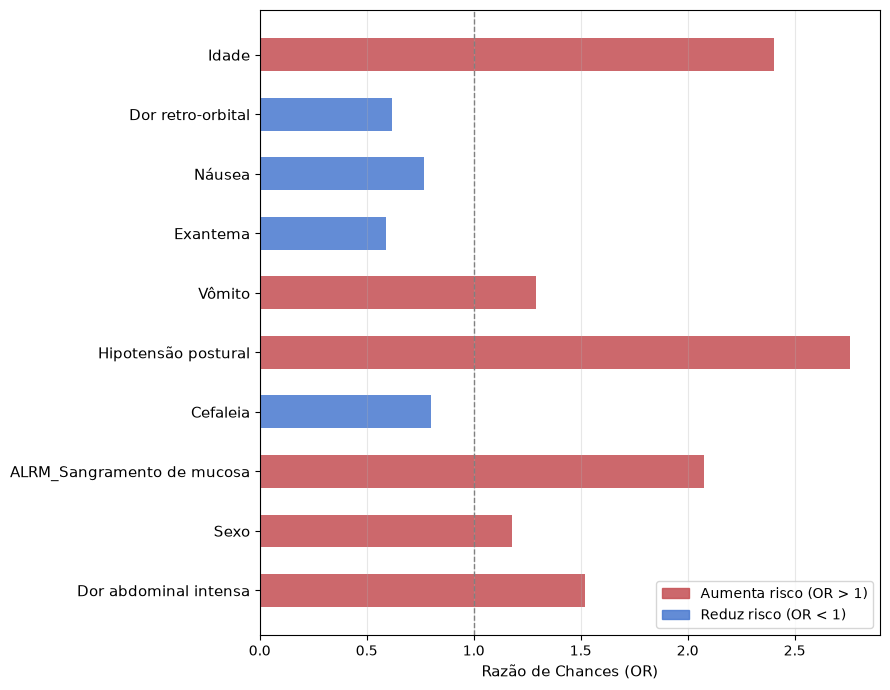

Salvo: output/plots/lr_odds_ratios_top10.png


In [22]:
import matplotlib.patches as mpatches

COR_RISK = '#C44E52'   # vermelho — aumenta risco (OR > 1)
COR_PROT = '#4878CF'   # azul    — reduz risco   (OR < 1)

FEATURE_LABELS = {
    'age_years': 'Idade', 'epi_week': 'Semana epidemiológica', 'year': 'Ano',
    'CS_SEXO': 'Sexo', 'CS_GESTANT': 'Gestante', 'CS_RACA': 'Raça/Cor',
    'CS_ESCOL_N': 'Escolaridade', 'SG_UF': 'UF de residência',
    'FEBRE': 'Febre', 'MIALGIA': 'Mialgia', 'CEFALEIA': 'Cefaleia',
    'EXANTEMA': 'Exantema', 'VOMITO': 'Vômito', 'NAUSEA': 'Náusea',
    'DOR_COSTAS': 'Dor nas costas', 'CONJUNTVIT': 'Conjuntivite',
    'ARTRITE': 'Artrite', 'ARTRALGIA': 'Artralgia', 'PETEQUIA_N': 'Petéquia',
    'LEUCOPENIA': 'Leucopenia', 'LACO': 'Prova do laço', 'DOR_RETRO': 'Dor retro-orbital',
    'DIABETES': 'Diabetes', 'HEMATOLOG': 'Doença hematológica',
    'HEPATOPAT': 'Hepatopatia', 'RENAL': 'Doença renal',
    'HIPERTENSA': 'Hipertensão arterial', 'AUTO_IMUNE': 'Doença autoimune',
    'ALRM_ABDOM': 'Dor abdominal intensa', 'ALRM_VOM': 'ALRM_Vômitos persistentes',
    'ALRM_LIQ': 'ALRM_Acúmulo de líquidos', 'ALRM_HEMAT': 'ALRM_Aumento do hematócrito',
    'ALRM_PLAQ': 'ALRM_Queda abrupta de plaquetas', 'ALRM_SANG': 'ALRM_Sangramento de mucosa',
    'ALRM_LETAR': 'ALRM_Letargia/irritabilidade', 'ALRM_HEPAT': 'ALRM_Hepatomegalia',
    'ALRM_HIPOT': 'Hipotensão postural',
    'GRAV_HIPOT': 'GRAV_Hipotensão arterial', 'GRAV_PULSO': 'GRAV_Pulso fraco e filiforme',
    'GRAV_EXTRE': 'GRAV_Extremidades frias', 'GRAV_ENCH': 'GRAV_Enchimento capilar lento',
    'GRAV_TAQUI': 'GRAV_Taquicardia', 'GRAV_CONV': 'GRAV_Convulsão',
    'GRAV_INSUF': 'GRAV_Insuficiência respiratória', 'GRAV_HEMAT': 'GRAV_Hematêmese',
    'GRAV_MELEN': 'GRAV_Melena', 'GRAV_METRO': 'GRAV_Metrorragia',
    'GRAV_SANG': 'GRAV_Sangramento intenso', 'GRAV_AST': 'GRAV_Astenia grave',
    'GRAV_MIOC': 'GRAV_Miocardite', 'GRAV_CONSC': 'GRAV_Alteração da consciência',
    'GRAV_ORGAO': 'GRAV_Disfunção orgânica',
}

# excluir variáveis de raça/cor (OR sem categoria de referência explícita)
df_plot = df_or[~df_or['feature'].str.startswith('CS_RACA')].head(TOP_N).copy()
df_plot['feature_pt'] = df_plot['feature'].map(FEATURE_LABELS).fillna(df_plot['feature'])

fig, ax = plt.subplots(figsize=(9, 7))
y_pos  = np.arange(len(df_plot))[::-1]
colors = [COR_RISK if row['OR'] > 1 else COR_PROT for _, row in df_plot.iterrows()]

ax.barh(y_pos, df_plot['OR'], color=colors, alpha=0.85, height=0.55)
ax.axvline(x=1, color='grey', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['feature_pt'], fontsize=11)
ax.set_xlabel('Razão de Chances (OR)', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(left=0)

legend_handles = [
    mpatches.Patch(color=COR_RISK, alpha=0.85, label='Aumenta risco (OR > 1)'),
    mpatches.Patch(color=COR_PROT, alpha=0.85, label='Reduz risco (OR < 1)'),
]
ax.legend(handles=legend_handles, fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'lr_odds_ratios_top10.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Salvo: output/plots/lr_odds_ratios_top10.png')